## NeuralNetwork and Deep Learning : Project 2 - The Street View House Numbers (SVHN) Dataset

# Import Data

In [ ]:
#import the input
import h5py
filename = "SVHN_single_grey1.h5"

h5 = h5py.File(filename,'r')

In [ ]:
#print the keys
list(h5.keys())

In [3]:
#Get the train and test data into different datasets
X_train = h5['X_train'][:]
X_test  = h5['X_test'][:]
y_train = h5['y_train'][:]
y_test  = h5['y_test'][:]

h5.close()

In [4]:
#Print the size of train and test features and output

In [5]:
X_train.shape

(42000, 32, 32)

In [6]:
X_test.shape

(18000, 32, 32)

In [7]:
y_train.shape

(42000,)

In [8]:
y_test.shape

(18000,)

In [9]:
import numpy as np

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [10]:
#The dataset consists of 42K training data and 18k test data.
#images size is 32x32
#There are 10 classes, 1 for each digit. Digit '1' has label 1, '9' has label 9 and '0' has label 10.

# Preprocess Data

In [11]:
#Convert in to 1D vector to match input dimensions of conv2D layers
#Reshape data from 2D to 1D
X_train = X_train.reshape(X_train.shape[0], 32, 32, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 32, 32, 1).astype('float32')

In [12]:
#Normalize after converting to float since we are using divide by 255 to normalize
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [13]:
import tensorflow as tf

#convert output to categorical data
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

C:\ProgramData\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\ProgramData\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\ProgramData\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\ProgramData\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:529: FutureWarning: Passi

In [14]:
X_train.shape

(42000, 32, 32, 1)

Label:  [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


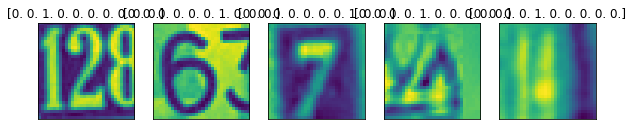

In [16]:
from matplotlib import pyplot as plt

#Visualize few sample images
fig, axes = plt.subplots(1, 5,figsize=(10, 10), sharey=True, sharex=True)

for i in range(5):
    axes[i].imshow(X_train[i].reshape(32,32))
    axes[i].set_title(y_train[i])
    
plt.xticks([])
plt.yticks([])

print('Label: ', y_train[0:5])

# Optimal k-Nearest Neighbor (kNN) classifier 

In [43]:
#Prepare flattened pixel array
index=0
knn_X_train=[]
for i in X_train:
    knn_X_train.append(np.array(X_train[index]).flatten())
    index=index+1
print(index, knn_X_train[1].shape, type(knn_X_train))

index=0
knn_X_test=[]
for i in X_test:
    knn_X_test.append(np.array(X_test[index]).flatten())
    index=index+1
print(index, knn_X_test[1].shape, type(knn_X_test))

42000 (1024,) <class 'list'>
18000 (1024,) <class 'list'>


In [44]:
#Use kfold cross validation to get no of neighbours

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn import metrics

# list of K for KNN
klist = list(range(1,10))
print(klist)


[1, 2, 3, 4, 5, 6, 7, 8, 9]


In [45]:
cv_scores = []
k_neighbors = []
# perform 10-fold cross validation
for k in klist:
    print(k)
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, knn_X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())
    k_neighbors.append(k)

1
2


KeyboardInterrupt: 

It takes many many hours to complete for so many samples and k values.
In the previous runs, the optimal number of neighbors obtained was 1. Hence using the same below by interrupting the above run.

In [46]:
MSE = [1 - x for x in cv_scores]
min(MSE)
MSE.index(min(MSE))
best_k = klist[MSE.index(min(MSE))]
print ("The optimal number of neighbors is %d" % best_k)

The optimal number of neighbors is 1


In [ ]:
#KNN model Implementation
knn_model = KNeighborsClassifier(n_neighbors= best_k , weights = 'distance' )
#fit
knn_model.fit(knn_X_train, y_train)
#predict
yPred = knn_model.predict(knn_X_test)
knn_model.score(knn_X_test, y_test) * 100

Test accuracy: 45.92%

Classification report for classifier KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=1, p=2,
                     weights='distance'):
              precision    recall  f1-score   support

           0       0.47      0.52      0.49      1814
           1       0.50      0.57      0.53      1828
           2       0.54      0.48      0.51      1803
           3       0.37      0.35      0.36      1719
           4       0.60      0.57      0.59      1812
           5       0.38      0.33      0.36      1768
           6       0.38      0.39      0.39      1832
           7       0.63      0.59      0.61      1808
           8       0.34      0.37      0.36      1812
           9       0.39      0.40      0.40      1804

       micro avg     0.46      0.46      0.46     18000
   
       macro avg       0.46      0.46      0.46     18000
   
    weighted avg       0.46      0.46      0.46     18000

     samples avg       0.46      0.46      0.46     18000

#  Classification metric report for KNN Model

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, yPred.round()))

# Feedforward Neural Network classifier and Backpropogation

In [17]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
from keras import regularizers
from keras import optimizers


import keras
import keras.utils
from keras import utils as np_utils

Using TensorFlow backend.


In [18]:
input_shape = (32, 32, 1)

In [19]:
#Initialize Sequential model
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(Dense(128, activation="relu"))

model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(Dense(128, activation="relu"))

model.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model.add(keras.layers.Dropout(0.25))

# Fully Connected Layer
model.add(Flatten()) # Flattening the 2D arrays for fully connected layers

model.add(Dense(128, activation="relu"))

model.add(keras.layers.Dropout(0.5))

# Prediction Layer
model.add(Dense(10, activation="softmax"))

model.summary()

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 30, 30, 32)        320       
_________________________________________________________________
dense_1 (Dense)              (None, 30, 30, 128)       4224      
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 28, 28, 32)        36896     
_________________________________________________________________
dense_2 (Dense)              (None, 28, 28, 128)       4224      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 128)       0         
_________________________________________________________________
dropout_1 (Dropout)  

In [20]:
# Loss and Optimizer
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
# simple early stopping
callback1 = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_acc',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

# Train the model
model.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          callbacks=callback1,
          validation_data=(X_test, y_test)
          )

Instructions for updating:
Use tf.cast instead.
Train on 42000 samples, validate on 18000 samples
Epoch 1/10
42000/42000 [==============================] - 761s 18ms/step - loss: 2.3026 - acc: 0.1031 - val_loss: 2.3020 - val_acc: 0.0996
Epoch 2/10
42000/42000 [==============================] - 721s 17ms/step - loss: 2.3018 - acc: 0.1077 - val_loss: 2.3011 - val_acc: 0.1281
Epoch 3/10
42000/42000 [==============================] - 832s 20ms/step - loss: 2.3007 - acc: 0.1144 - val_loss: 2.2991 - val_acc: 0.1172
Epoch 4/10
42000/42000 [==============================] - 1079s 26ms/step - loss: 2.2973 - acc: 0.1275 - val_loss: 2.2915 - val_acc: 0.1658
Epoch 5/10
42000/42000 [==============================] - 675s 16ms/step - loss: 2.2813 - acc: 0.1573 - val_loss: 2.2412 - val_acc: 0.2304
Epoch 6/10
42000/42000 [==============================] - 648s 15ms/step - loss: 2.1072 - acc: 0.2550 - val_loss: 1.8264 - val_acc: 0.4170
Epoch 00006: early stopping


In [23]:
# summarize history for accuracy
#plt.plot(model.history['acc'])
#plt.plot(model.history['val_acc'])
#plt.title('CNN Model Accuracy')
#plt.ylabel('accuracy')
#plt.xlabel('epoch')
#plt.legend(['Train', 'Validation'], loc='upper left')
#plt.show()
# summarize history for loss
#plt.plot(model.history['loss'])
#plt.plot(model.history['val_loss'])
#plt.title('CNN Model Loss')
#plt.ylabel('loss')
#plt.xlabel('epoch')
#plt.legend(['Train', 'Validation'], loc='upper left')
#plt.show()

In [24]:
model.evaluate(X_train, y_train)

42000/42000 [==============================] - 146s 3ms/step


[1.82393003091358, 0.4185238095238095]

In [25]:
model.evaluate(X_test, y_test)

18000/18000 [==============================] - 63s 4ms/step


[1.8264086475372314, 0.417]

In [26]:
#Predict the test data
yPred = model.predict(X_test, verbose=2)

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, yPred.round()))

              precision    recall  f1-score   support

           0       1.00      0.00      0.01      1814
           1       0.90      0.14      0.24      1828
           2       1.00      0.05      0.09      1803
           3       0.89      0.07      0.13      1719
           4       0.94      0.25      0.39      1812
           5       1.00      0.00      0.01      1768
           6       0.79      0.07      0.13      1832
           7       0.93      0.19      0.32      1808
           8       1.00      0.00      0.00      1812
           9       0.00      0.00      0.00      1804

   micro avg       0.91      0.08      0.14     18000
   macro avg       0.84      0.08      0.13     18000
weighted avg       0.84      0.08      0.13     18000
 samples avg       0.08      0.08      0.08     18000



# DL Model With Batch Normalization

In [37]:
from keras.layers import BatchNormalization

#Initialize Sequential model
model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(BatchNormalization(input_shape=input_shape))
model.add(Dense(128, activation="relu"))

model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(BatchNormalization(input_shape=input_shape))
model.add(Dense(128, activation="relu"))

model.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model.add(keras.layers.Dropout(0.25))

# Fully Connected Layer
model.add(Flatten()) # Flattening the 2D arrays for fully connected layers

model.add(Dense(128, activation="relu"))

model.add(keras.layers.Dropout(0.5))

# Prediction Layer
model.add(Dense(10, activation="softmax"))

model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            (None, 30, 30, 32)        320       
_________________________________________________________________
batch_normalization_1 (Batch (None, 30, 30, 32)        128       
_________________________________________________________________
dense_5 (Dense)              (None, 30, 30, 128)       4224      
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 28, 28, 32)        36896     
_________________________________________________________________
batch_normalization_2 (Batch (None, 28, 28, 32)        128       
_________________________________________________________________
dense_6 (Dense)              (None, 28, 28, 128)       4224      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 14, 14, 128)       0         
__________

In [38]:
# Loss and Optimizer
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [39]:
# simple early stopping
callback1 = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_acc',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        mode='min',
        verbose=1)
]

# Train the model
model.fit(X_train, y_train,
          epochs=10,
          batch_size=64,
          callbacks=callback1,
          validation_data=(X_test, y_test)
          )

Train on 42000 samples, validate on 18000 samples
Epoch 1/10
42000/42000 [==============================] - 945s 22ms/step - loss: 1.6464 - acc: 0.4212 - val_loss: 1.0068 - val_acc: 0.6932
Epoch 2/10
42000/42000 [==============================] - 957s 23ms/step - loss: 0.7613 - acc: 0.7567 - val_loss: 1.0241 - val_acc: 0.6749
Epoch 3/10
42000/42000 [==============================] - 953s 23ms/step - loss: 0.6052 - acc: 0.8108 - val_loss: 0.5855 - val_acc: 0.8264
Epoch 4/10
42000/42000 [==============================] - 1005s 24ms/step - loss: 0.5338 - acc: 0.8330 - val_loss: 0.7807 - val_acc: 0.7598
Epoch 5/10
42000/42000 [==============================] - 1075s 26ms/step - loss: 0.4918 - acc: 0.8484 - val_loss: 0.6314 - val_acc: 0.7979
Epoch 6/10
42000/42000 [==============================] - 988s 24ms/step - loss: 0.4542 - acc: 0.8565 - val_loss: 0.4389 - val_acc: 0.8676
Epoch 7/10
42000/42000 [==============================] - 967s 23ms/step - loss: 0.4224 - acc: 0.8682 - val_loss: 

In [40]:
model.evaluate(X_train, y_train)

42000/42000 [==============================] - 217s 5ms/step


[0.547720241637457, 0.8275476190476191]

In [41]:
model.evaluate(X_test, y_test)

18000/18000 [==============================] - 94s 5ms/step


[0.6083310554822285, 0.8116111111111111]

In [42]:
#Predict the test data
yPred = model.predict(X_test, verbose=2)

from sklearn.metrics import classification_report
print(classification_report(y_test, yPred.round()))

              precision    recall  f1-score   support

           0       0.98      0.69      0.81      1814
           1       0.82      0.84      0.83      1828
           2       0.89      0.82      0.85      1803
           3       0.88      0.66      0.75      1719
           4       0.93      0.75      0.83      1812
           5       0.90      0.78      0.83      1768
           6       0.89      0.73      0.81      1832
           7       0.93      0.83      0.88      1808
           8       0.91      0.73      0.81      1812
           9       0.90      0.74      0.81      1804

   micro avg       0.90      0.76      0.82     18000
   macro avg       0.90      0.76      0.82     18000
weighted avg       0.90      0.76      0.82     18000
 samples avg       0.76      0.76      0.76     18000



# Analysis

Perfomance and Memory requirements is high for KNN. It took long time and used high memory to execute the KNN model.
The acurracy is high for CNN as compared to KNN. The difference is because CNN extracts features through convolution layer whereas KNN processes the raw pixel data.

CNN each epoch took about 10mins without batch normalization.

CNN each epoch took about 16mins with batch normalization. But the accuracy and model score increased very much in the initial epocs itself and helped not over fit to train data. Also the scores improved well with batch normalization.

KNN took many many hours for cross validation which is impractical without GPU support.


With Batch Normalization, the model's learning performance is faster. 
(It is expected due to Covariate shift by normalizing the activations of each layer ie., transforming the inputs to be mean 0 and unit variance. This, supposedly, allows each layer to learn on a more stable distribution of inputs, and would thus accelerate the training of the network. Thanks to https://mlexplained.com/ website for helping me learn this)